In [1]:
import pandas as pd

In [2]:
data_prefix = '../data_curation/processed_data/'


In [3]:
data = pd.read_parquet(data_prefix + 'final_dataset_RDKit_50.parquet').drop(columns=['SMILES'])
data


,MP,Type,Ro5,RDKit_fr_hdrzone,RDKit_PEOE_VSA7,RDKit_EState_VSA2,RDKit_EState_VSA6,RDKit_BalabanJ,RDKit_BCUT2D_LOGPHI,RDKit_EState_VSA1,...,RDKit_SMR_VSA10,RDKit_VSA_EState3,RDKit_SlogP_VSA3,RDKit_fr_priamide,RDKit_SlogP_VSA2,RDKit_fr_Ar_OH,RDKit_fr_allylic_oxid,RDKit_NumAliphaticCarbocycles,RDKit_NHOHCount,RDKit_Chi2v
0,176.35,Train,1,0,36.101280,17.250175,13.847474,2.014907,2.551776,23.774423,...,11.938611,9.899269,14.325937,0,23.149104,0,0,3,1,6.710426
1,142.75,Train,1,0,85.868178,6.103966,0.000000,1.626966,2.643377,0.000000,...,0.000000,10.039826,0.000000,0,11.210494,0,2,4,1,8.767699
2,53.50,Train,1,0,11.126903,0.000000,0.000000,2.348638,2.095369,0.000000,...,17.082441,0.000000,0.000000,0,4.864567,0,0,0,0,3.469423
3,37.00,Train,1,0,18.553556,0.000000,6.066367,3.296882,2.158668,0.000000,...,17.887100,0.523148,0.000000,0,6.286161,0,0,0,0,2.495460
4,63.00,Train,1,0,12.132734,0.000000,0.000000,2.675200,2.278513,0.000000,...,28.005805,2.570370,0.000000,0,4.567100,0,0,0,0,3.586875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17215,259.00,Test,1,0,24.265468,11.470631,12.132734,2.809454,2.084171,5.969305,...,17.563871,11.109298,4.794537,0,16.983012,0,0,0,2,2.563689
17216,136.50,Test,1,0,12.132734,13.213764,18.199101,2.508195,2.027504,12.186480,...,12.186480,4.661947,22.687490,0,31.265803,0,0,0,2,3.272527
17217,145.00,Test,1,0,11.629819,5.153110,12.263211,2.523518,2.215839,0.000000,...,11.600940,9.062723,0.000000,0,4.983979,0,0,0,0,3.398205
17218,100.00,Test,1,0,29.828920,5.783245,0.000000,1.965290,2.146947,0.000000,...,5.783245,0.000000,6.606882,0,5.783245,0,0,0,0,4.075381


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.base import clone

import lightgbm as lgb
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')


In [15]:
# ── Helper functions ─────────────────────────────────────────────────────────

def split_data(data, type_col, label_col, target_col):
    """
    Split dataset into train/test sets and further partition by Ro5 label.

    Returns a dict:
        {
          'train': {'Overall': (X, y), 'Ro5': (X, y), 'bRo5': (X, y)},
          'test':  {'Overall': (X, y), 'Ro5': (X, y), 'bRo5': (X, y)},
        }
    """
    feature_cols = [c for c in data.columns if c not in [type_col, label_col, target_col]]

    train_df = data[data[type_col] == 'Train']
    test_df  = data[data[type_col] == 'Test']

    def get_Xy(df, subset):
        if subset == 'Ro5':
            df = df[df[label_col] == 1]
        elif subset == 'bRo5':
            df = df[df[label_col] == 0]
        return df[feature_cols].values, df[target_col].values

    subsets = ['Overall', 'Ro5', 'bRo5']
    return {
        'train': {s: get_Xy(train_df, s) for s in subsets},
        'test':  {s: get_Xy(test_df,  s) for s in subsets},
    }


def get_models():
    """Return default-hyperparameter model instances keyed by short name."""
    return {
        'DT':  DecisionTreeRegressor(random_state=42),
        'LGB': lgb.LGBMRegressor(random_state=42, verbose=-1),
        'XGB': xgb.XGBRegressor(random_state=42, verbosity=0),
        # 'MLR': LinearRegression(),
        'RF':  RandomForestRegressor(random_state=42),
        'SVR': SVR(),
    }


def compute_metrics(model, X_test, y_test):
    """Return RMSE and R2 for a fitted model on a given test set."""
    y_pred = model.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    mae    = mean_absolute_error(y_test, y_pred)
    return {'RMSE': round(rmse, 4), 'R2': round(r2, 4), 'MAE': round(mae, 4)}


def train_and_evaluate(base_model, splits):
    """
    Train Overall / Ro5 / bRo5 variants of one algorithm and evaluate
    each variant against all three test subsets.

    Returns a list of dicts: {Train_on, Test_on, RMSE, R2, MAE}.
    """
    rows = []
    for train_name in ['Overall', 'Ro5', 'bRo5']:
        X_tr, y_tr = splits['train'][train_name]
        model = clone(base_model)
        model.fit(X_tr, y_tr)

        for test_name in ['Overall', 'Ro5', 'bRo5']:
            X_te, y_te = splits['test'][test_name]
            metrics = compute_metrics(model, X_te, y_te)
            rows.append({'Train_on': train_name, 'Test_on': test_name, **metrics})
    return rows


def build_results_df(all_results):
    """Flatten per-model result lists into a single tidy DataFrame."""
    rows = []
    for model_name, model_rows in all_results.items():
        for row in model_rows:
            rows.append({'Model': model_name, **row})
    return pd.DataFrame(rows)


def plot_results(df):
    """
    Visualise results in a 3 x 3 grid:
      - rows  : metric (RMSE, R2, MAE)
      - cols  : test subset (Overall, Ro5, bRo5)
      - x-axis: algorithm
      - hue   : training subset (Overall, Ro5, bRo5)
    """
    metrics   = ['RMSE', 'R2', 'MAE']
    test_sets = ['Overall', 'Ro5', 'bRo5']
    palette   = sns.color_palette('Set2', 3)

    fig, axes = plt.subplots(len(metrics), len(test_sets), figsize=(18, 10))

    for i, metric in enumerate(metrics):
        for j, test_name in enumerate(test_sets):
            ax     = axes[i][j]
            subset = df[df['Test_on'] == test_name]
            pivot  = subset.pivot(index='Model', columns='Train_on', values=metric)
            pivot  = pivot[['Overall', 'Ro5', 'bRo5']]   # consistent column order

            pivot.plot(kind='bar', ax=ax, color=palette, edgecolor='white', width=0.72)
            ax.set_title(f'{metric}  |  Test: {test_name}', fontweight='bold')
            ax.set_xlabel('')
            ax.set_ylabel(metric)
            ax.tick_params(axis='x', rotation=45)
            ax.legend(title='Trained on', fontsize=8)
            if metric == 'R2':
                ax.set_ylim(bottom=min(-0.1, df['R2'].min() - 0.05), top=1.05)

    fig.suptitle(
        'Model Comparison — RMSE, R2 & MAE across Training and Test Subsets',
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()
    return fig


In [16]:
# ── Main function ─────────────────────────────────────────────────────────────

def model_comparison(data=data, type='Type', label='Ro5', target='MP'):
    """
    Train and compare DT, LGB, XGB, MLR, RF, and SVR models on three
    training subsets (Overall, Ro5, bRo5) and evaluate each on three
    test subsets (Overall, Ro5, bRo5).

    Training subsets
    ----------------
    Overall : all training molecules
    Ro5     : training molecules where label == 1
    bRo5    : training molecules where label == 0

    Test subsets
    ------------
    Overall : all test molecules
    Ro5     : test molecules where label == 1
    bRo5    : test molecules where label == 0

    Parameters
    ----------
    data   : pd.DataFrame — dataset containing type, label, and target columns
    type   : str          — column that flags Train / Test split
    label  : str          — column with Ro5 membership (1 = Ro5, 0 = bRo5)
    target : str          — regression target column

    Returns
    -------
    pd.DataFrame with columns: Model, Train_on, Test_on, RMSE, R2
    """
    print('Splitting data...')
    splits = split_data(data, type, label, target)

    train_sizes = {k: splits['train'][k][0].shape[0] for k in ['Overall', 'Ro5', 'bRo5']}
    test_sizes  = {k: splits['test'][k][0].shape[0]  for k in ['Overall', 'Ro5', 'bRo5']}
    print(f"  Train sizes  — Overall: {train_sizes['Overall']}, Ro5: {train_sizes['Ro5']}, bRo5: {train_sizes['bRo5']}")
    print(f"  Test sizes   — Overall: {test_sizes['Overall']},  Ro5: {test_sizes['Ro5']},  bRo5: {test_sizes['bRo5']}")

    models = get_models()
    all_results = {}

    print('\nTraining models...')
    for model_name, model in models.items():
        print(f'  {model_name:<4} ... ', end='', flush=True)
        all_results[model_name] = train_and_evaluate(model, splits)
        print('done')

    results_df = build_results_df(all_results)

    print('\n=== Results Table ===')
    display(
        results_df
        .set_index(['Model', 'Train_on', 'Test_on'])
        .sort_index()
        .style.background_gradient(subset=['RMSE'], cmap='RdYlGn_r')
               .background_gradient(subset=['R2'],   cmap='RdYlGn')
               .format({'RMSE': '{:.4f}', 'R2': '{:.4f}'})
    )

    plot_results(results_df)

    return results_df


Splitting data...
  Train sizes  — Overall: 8610, Ro5: 8427, bRo5: 183
  Test sizes   — Overall: 8610,  Ro5: 8426,  bRo5: 184

Training models...
  DT   ... done
  LGB  ... done
  XGB  ... done
  RF   ... done
  SVR  ... done

=== Results Table ===


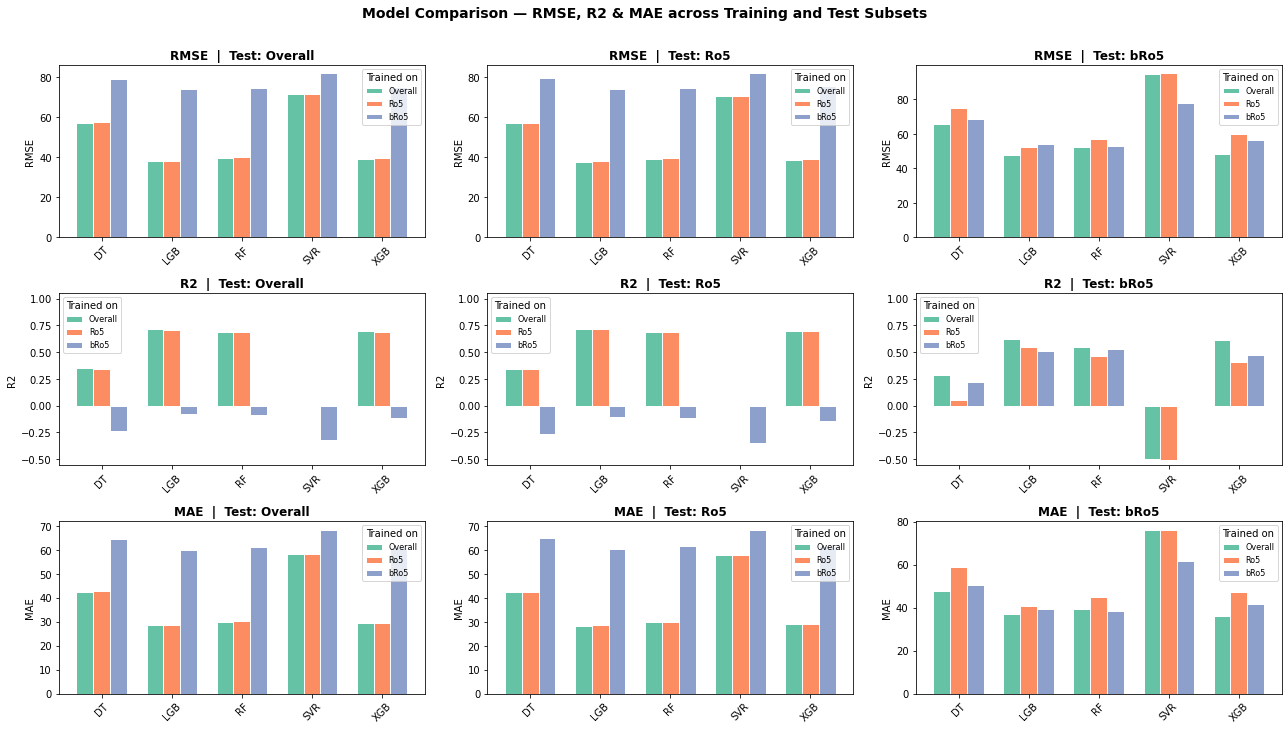

In [17]:
results = model_comparison(data=data, type='Type', label='Ro5', target='MP')
